In [36]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

In [37]:
df=pd.read_csv("csv//processed_data.csv")

In [38]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [40]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
logi_model = LogisticRegression()
logi_model.fit(X_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [42]:
pred_logi= logi_model.predict(X_test_scaled)

prob_logi = logi_model.predict_proba(X_test_scaled)[:,1]

In [43]:
print("Accuracy :", accuracy_score(y_test, pred_logi))
print("Precision:", precision_score(y_test, pred_logi))
print("Recall   :", recall_score(y_test, pred_logi))
print("F1 Score :", f1_score(y_test, pred_logi))
print("ROC AUC  :", roc_auc_score(y_test, prob_logi))

Accuracy : 0.801277501774308
Precision: 0.6566666666666666
Recall   : 0.5267379679144385
F1 Score : 0.5845697329376854
ROC AUC  : 0.8429564184039887


In [45]:
print(classification_report(y_test, pred_logi))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



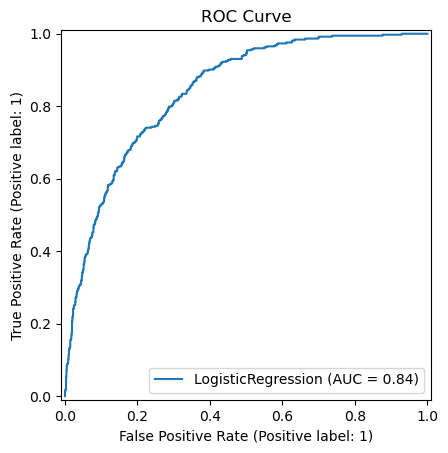

In [46]:
RocCurveDisplay.from_estimator(
    logi_model,
    X_test_scaled,
    y_test
)

plt.title("ROC Curve")

plt.show()

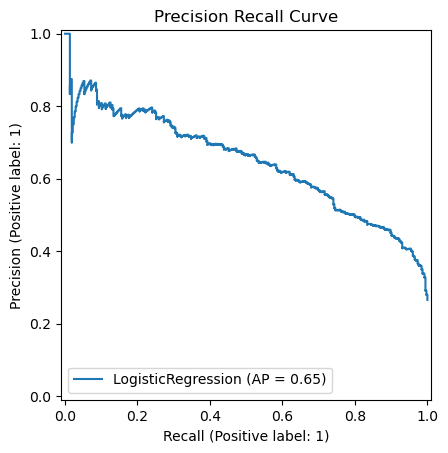

In [47]:
PrecisionRecallDisplay.from_estimator(
    logi_model,
    X_test_scaled,
    y_test
)

plt.title("Precision Recall Curve")

plt.show()

In [48]:
coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": logi_model.coef_[0]
})

coef["Absolute"] = coef["Coefficient"].abs()

coef = coef.sort_values(
    by="Absolute",
    ascending=False
)

coef.head(15)

,Feature,Coefficient,Absolute
0,tenure,-1.479926,1.479926
2,TotalCharges,-1.149281,1.149281
10,InternetService_Fiber optic,0.766790,0.766790
34,TenureGroup_61-72,0.737371,0.737371
1,MonthlyCharges,-0.717540,0.717540
41,TotalChargesGroup_7001-8000,0.691957,0.691957
40,TotalChargesGroup_6001-7000,0.688574,0.688574
25,Contract_Two year,-0.640363,0.640363
39,TotalChargesGroup_5001-6000,0.601091,0.601091
33,TenureGroup_49-60,0.505136,0.505136


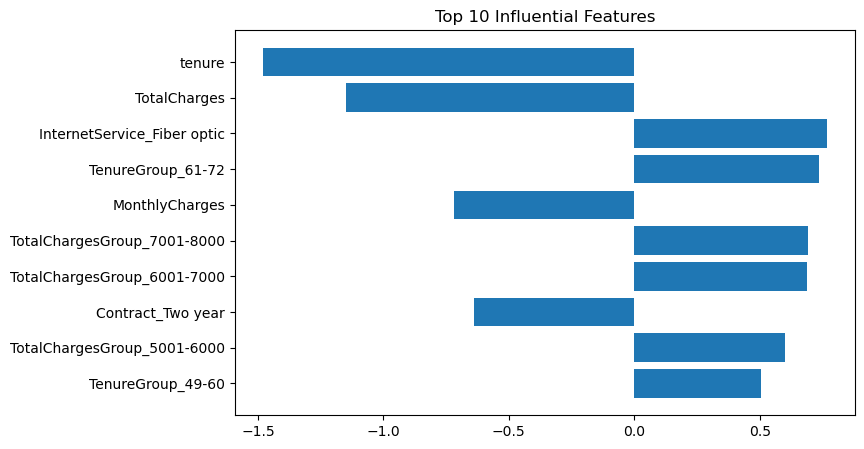

In [49]:
top = coef.head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top["Feature"],
    top["Coefficient"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Influential Features")

plt.show()

In [51]:
import joblib

joblib.dump(logi_model, "models/final_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")

['models/scaler.pkl']